In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

file_name = "cleaned_customer_shopping_data.csv"
matches = list(Path.cwd().parent.rglob(file_name))

if not matches:
  raise FileNotFoundError(
    f"{file_name} was not found under {Path.cwd()}. "
    "Check that the dataset file is in the project folder."
  )

df_clean = pd.read_csv(matches[0])
print('Dataframe loaded successfully')
print(df_clean.shape)
df_clean.head()

Dataframe loaded successfully
(10000, 32)


,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Review Rating,Return Status,Previous Purchases,Frequency of Purchases,Purchase_Year,Purchase_Month,Purchase_DayOfWeek,Is_Returned,Is_Subscribed,Purchase_Frequency_Days
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,4,Not Returned,0,Fortnightly,2023,1,6,0,1,14
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,Not online store,Clothing,Shirt,...,5,Not Returned,0,Fortnightly,2023,1,6,0,0,14
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,3,Not Returned,0,Rarely,2023,1,6,0,1,180
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,4,Not Returned,0,Fortnightly,2023,1,6,0,1,14
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,4,Not Returned,0,Weekly,2023,1,6,0,0,7


In [2]:
# 1. Structural Inspection
print("--- Dataset Shape ---")
print(df_clean.shape)
print("\n--- Data Types & Missing Values ---")
print(df_clean.info())

# 2. Check for explicit missing values
print("\n--- Missing Values Count ---")
print(df_clean.isnull().sum())

# 3. Data Cleaning & Type Conversions
# Convert Date to datetime object
df_clean['Purchase Date'] = pd.to_datetime(df_clean['Purchase Date'])
# Extract time features
df_clean['Purchase Month'] = df_clean['Purchase Date'].dt.month
df_clean['Purchase DayOfWeek'] = df_clean['Purchase Date'].dt.dayofweek

print("\n--- Statistical Summary of Numerical Fields ---")
print(df_clean.describe())

--- Dataset Shape ---
(10000, 32)

--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Transaction ID           10000 non-null  object
 1   Customer ID              10000 non-null  object
 2   Purchase Date            10000 non-null  object
 3   Age                      10000 non-null  int64 
 4   Gender                   10000 non-null  object
 5   Location                 10000 non-null  object
 6   Online/Offline           10000 non-null  object
 7   Online Store             10000 non-null  object
 8   Category                 10000 non-null  object
 9   Item Purchased           10000 non-null  object
 10  Brand                    10000 non-null  object
 11  Color                    10000 non-null  object
 12  Size                     10000 non-null  object
 13  Quantity             

In [3]:
# Preview the cleaned dataframe
df_clean.head()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Previous Purchases,Frequency of Purchases,Purchase_Year,Purchase_Month,Purchase_DayOfWeek,Is_Returned,Is_Subscribed,Purchase_Frequency_Days,Purchase Month,Purchase DayOfWeek
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,0,Fortnightly,2023,1,6,0,1,14,1,6
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,Not online store,Clothing,Shirt,...,0,Fortnightly,2023,1,6,0,0,14,1,6
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,0,Rarely,2023,1,6,0,1,180,1,6
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,0,Fortnightly,2023,1,6,0,1,14,1,6
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,0,Weekly,2023,1,6,0,0,7,1,6


--- Overall Return Rate ---
18.02%


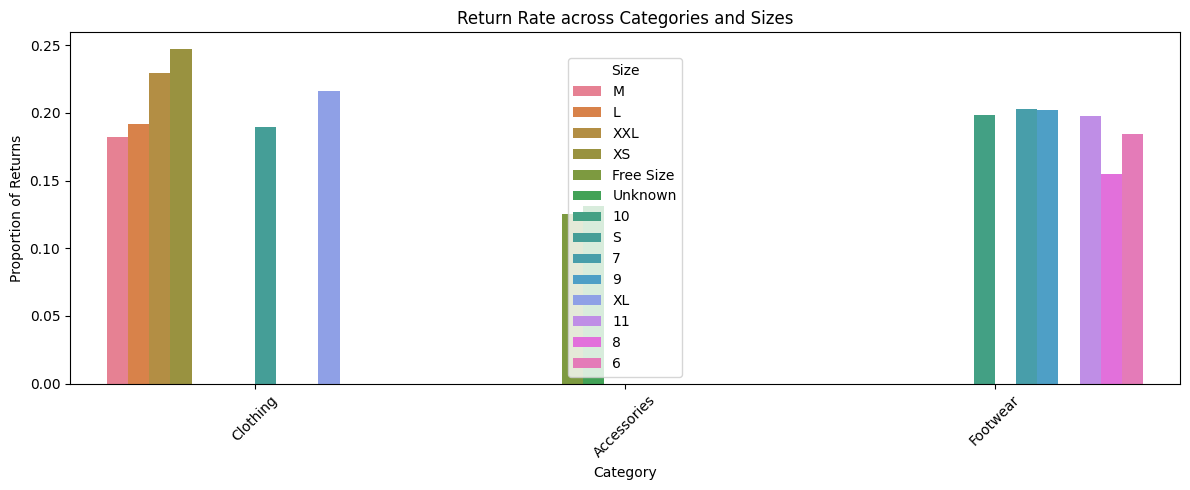

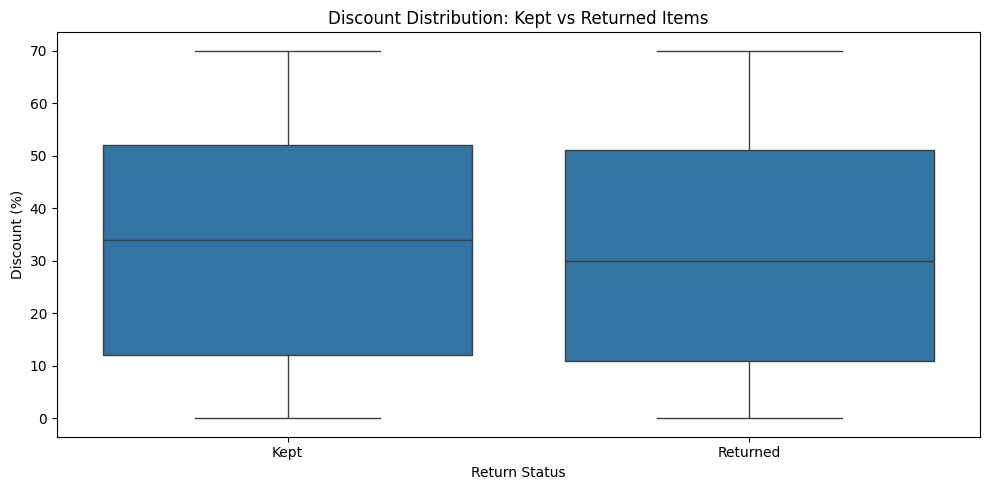

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a binary return indicator from the cleaned return-status values.
df_clean['Is_Returned'] = (
    df_clean['Return Status']
    .astype('string')
    .str.strip()
    .str.lower()
    .eq('returned')
    .astype(int)
)

print("--- Overall Return Rate ---")
print(f"{df_clean['Is_Returned'].mean() * 100:.2f}%")

# 1. Return Rate by Category and Size
plt.figure(figsize=(12, 5))
sns.barplot(
    data=df_clean,
    x='Category',
    y='Is_Returned',
    hue='Size',
    errorbar=None
)
plt.title('Return Rate across Categories and Sizes')
plt.ylabel('Proportion of Returns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Does higher discount lead to more returns?
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Is_Returned', y='Discount (%)')
plt.title('Discount Distribution: Kept vs Returned Items')
plt.xlabel('Return Status')
plt.ylabel('Discount (%)')
plt.xticks([0, 1], ['Kept', 'Returned'])
plt.tight_layout()
plt.show()

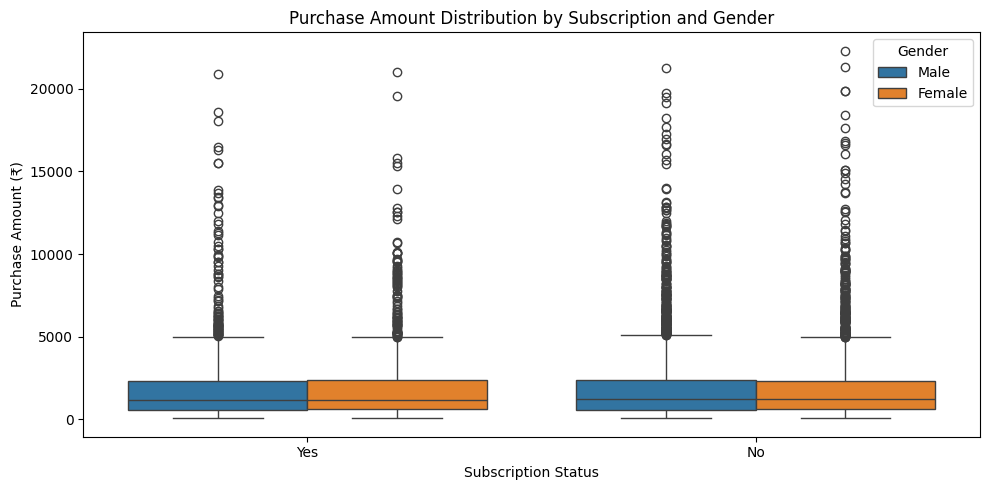

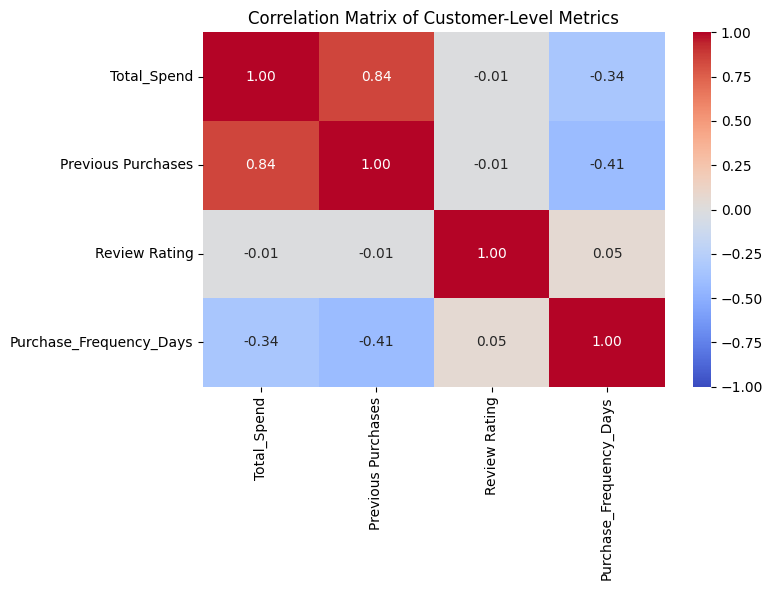

In [3]:
# 1. Spending Distribution by Subscription & Gender
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_clean,
    x='Subscription Status',
    y='Purchase Amount (₹)',
    hue='Gender'
)
plt.title('Purchase Amount Distribution by Subscription and Gender')
plt.xlabel('Subscription Status')
plt.ylabel('Purchase Amount (₹)')
plt.tight_layout()
plt.show()

# 2. Correlation between Loyalty Metrics and Spend
# Convert the categorical purchase frequency into approximate days first.
frequency_days = {
    'Weekly': 7,
    'Fortnightly': 14,
    'Monthly': 30,
    'Quarterly': 90,
    'Rarely': 180
}

customer_eda = df_clean.groupby('Customer ID').agg({
    'Purchase Amount (₹)': 'sum',
    'Previous Purchases': 'max',
    'Frequency of Purchases': 'first',
    'Review Rating': 'mean'
}).rename(columns={'Purchase Amount (₹)': 'Total_Spend'})

customer_eda['Purchase_Frequency_Days'] = (
    customer_eda['Frequency of Purchases'].map(frequency_days)
)
customer_eda = customer_eda.drop(columns='Frequency of Purchases')

correlation_matrix = customer_eda.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)
plt.title('Correlation Matrix of Customer-Level Metrics')
plt.tight_layout()
plt.show()

🏷️ Goal 3: Optimizing Discounts (Price Elasticity & Analytics)To optimize discounts, we need to understand the sweet spot where Discount (%) maximizes Quantity or Purchase Amount (₹) without destroying profit margins, especially during a Festival/Sale.

                                       Purchase Amount (₹)  Quantity  \
Festival/Sale            Discount (%)                                  
Amazon Great Summer Sale 0                           26811  1.833333   
                         1                           27593  1.222222   
                         2                           37379  1.523810   
                         3                           30126  1.148148   
                         4                           45672  1.297297   
                         5                           44828  1.366667   
                         6                           46986  1.592593   
                         7                           32616  1.250000   
                         8                           29234  1.384615   
                         9                           30821  1.440000   

                                       Return Status  
Festival/Sale            Discount (%)                 
Amazon Great Summer Sale 

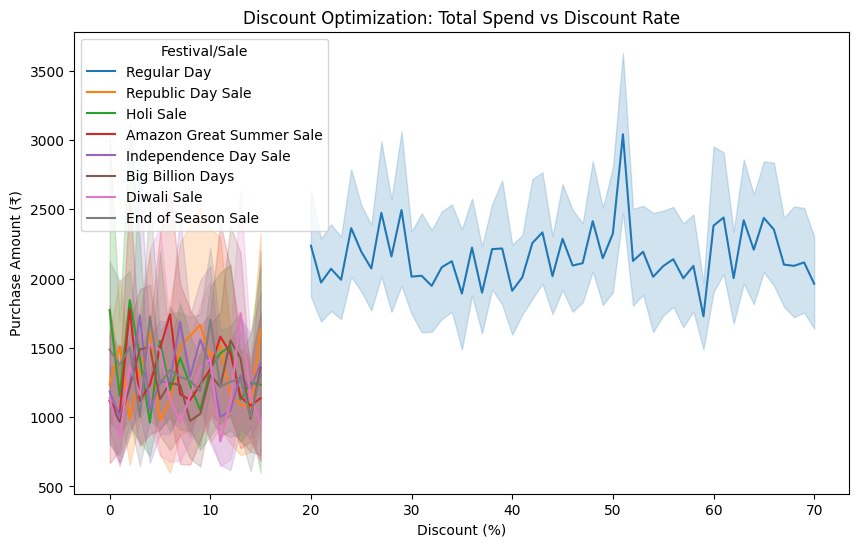

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Analyze impact of discounts on Quantity during Sales vs Regular days
pivot_discount = df_clean.pivot_table(
    values=['Quantity', 'Purchase Amount (₹)', 'Return Status'], 
    index=['Festival/Sale', 'Discount (%)'], 
    aggfunc={'Quantity': 'mean', 'Purchase Amount (₹)': 'sum', 'Return Status': lambda x: (x == 'Returned').mean()}
)
print(pivot_discount.head(10))

# 2. Visualizing the Sweet Spot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_clean, x='Discount (%)', y='Purchase Amount (₹)', hue='Festival/Sale')
plt.title('Discount Optimization: Total Spend vs Discount Rate')
plt.show()

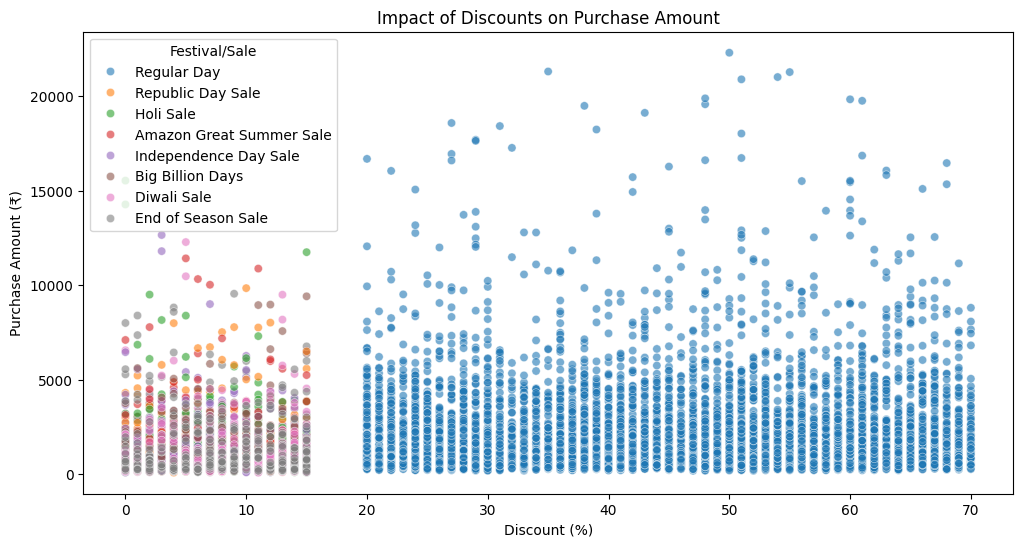

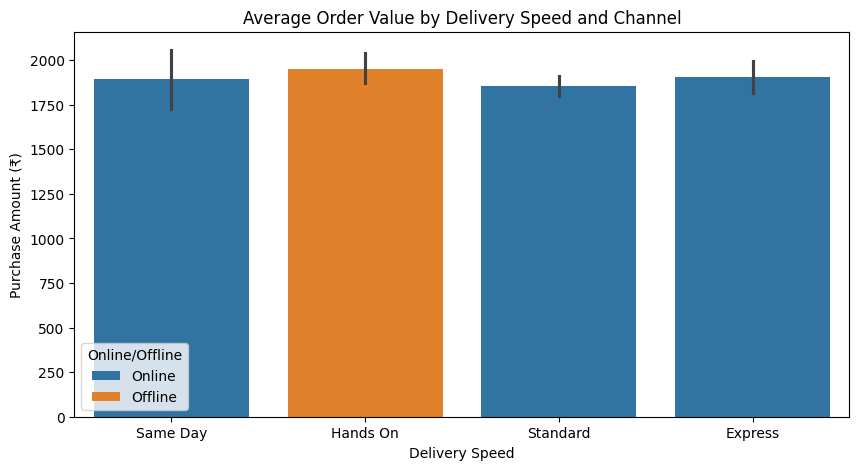

In [5]:
# 1. Discount vs Purchase Amount during Festivals
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_clean, x='Discount (%)', y='Purchase Amount (₹)', hue='Festival/Sale', alpha=0.6)
plt.title('Impact of Discounts on Purchase Amount')
plt.show()

# 2. Delivery Speed and Shipping Charges impact on Volume
plt.figure(figsize=(10, 5))
sns.barplot(data=df_clean, x='Delivery Speed', y='Purchase Amount (₹)', hue='Online/Offline')
plt.title('Average Order Value by Delivery Speed and Channel')
plt.show()